In [ ]:
import os
import sys
import warnings
from collections import deque

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning, message=".*resized since it had shape.*")

In [ ]:
if os.path.abspath("../package") not in sys.path:
    sys.path.append(os.path.abspath("../package"))

In [ ]:
from package.environment import build_environment
from package.module import Rainbow, DuelingDistributionHead, BreakoutBackbone, ScaleModule
from package.actor import DistributionActor
from package.utils import build_buffer, progress, save_video_opencv
from package.td_view import to_transition, Transition
from package.optim import DistributionalLoss, SoftUpdate, DQNOptimizer

In [ ]:
import torch
import torch.nn as nn
from tensordict.nn import TensorDictModule, TensorDictSequential
from torchrl.envs import GymWrapper
from torchrl.collectors import Collector

In [ ]:
environment: GymWrapper = build_environment()
_ = environment.reset()

In [ ]:
# --- Гиперпараметры цикла обучения ---
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
TOTAL_FRAMES: int = 2_000_000  # всего кадров среды за прогон
FRAMES_PER_BATCH: int = 4  # сколько кадров собираем за одну итерацию
BATCH_SIZE: int = 32  # размер батча из буфера
UPDATES_PER_BATCH: int = 1  # градиентных шагов на один собранный батч
MIN_BUFFER: int = 20_000  # прогрев: не учимся, пока в буфере меньше переходов
BUFFER: int = 1_000_000  # Размер буфера.
LOG_INTERVAL: int = 500  # печатать статистику раз в N итераций
CKPT_PATH: str = "../experience/results-2/staff/logs/main/checkpoint/Sequential/weights_1783499039.9051886.pt"
BUFFER_DIR: str = "buffer"

In [ ]:
buf = build_buffer(size=TOTAL_FRAMES, device=DEVICE, directory=BUFFER_DIR, alpha=0.5, beta=0.4, gamma=0.99, n_steps=3)
dqn = nn.Sequential(ScaleModule(1. / 255.), Rainbow(BreakoutBackbone(), DuelingDistributionHead(4, 51)))
policy = TensorDictSequential(TensorDictModule(module=dqn, in_keys=["observation"], out_keys=["logits"]),
                              TensorDictModule(module=DistributionActor(), in_keys=["logits"], out_keys=["action"]))

In [ ]:
policy = policy.to(DEVICE)

In [ ]:
if os.path.exists(CKPT_PATH):
    dqn.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
    print(f"loaded -> {CKPT_PATH}")
else:
    print("No checkpoint found.")
    _ = policy(environment.fake_tensordict().to(DEVICE))
    print("Weights initialized.")

In [ ]:
td = environment.rollout(max_steps=1500, policy=policy, auto_cast_to_device=True, break_when_any_done=False)

In [ ]:
save_video_opencv(td["observation"], fps=30)

In [ ]:
collector = Collector(build_environment,
                      frames_per_batch=FRAMES_PER_BATCH,
                      total_frames=MIN_BUFFER,
                      policy_device=DEVICE)
# -----------------------------------
for it, td in enumerate(collector, start=1):
    buf.extend(to_transition(td).td)
    progress(it, len(collector), "Filling the buffer.")

In [ ]:
loss_module = DistributionalLoss(dqn).to(DEVICE)
target_updater = SoftUpdate(loss_module, tau=5e-3)
optimizer = torch.optim.Adam(dqn.parameters(), lr=6.25e-5, eps=1.5e-4)
scheduler = None  # LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=TOTAL_FRAMES // 4)
optim = DQNOptimizer(loss_function=loss_module,
                     target_updater=target_updater,
                     optimizer=optimizer,
                     scheduler=scheduler,
                     grad_norm=10.0)

In [ ]:
collector = Collector(build_environment,
                      policy=policy,
                      frames_per_batch=FRAMES_PER_BATCH,
                      total_frames=TOTAL_FRAMES,
                      policy_device=DEVICE)
total_iters: int = len(collector)
# -----------------------------------
reward_window: deque = deque(maxlen=100)
episode_return: float = 0.0
collected: int = 0
# -----------------------------------
for it, td in enumerate(collector, start=1):
    buf.extend(to_transition(td).td)
    collected += td.numel()
    rewards = td["next", "reward"].reshape(-1).tolist()
    dones = td["next", "done"].reshape(-1).tolist()
    for r, d in zip(rewards, dones):
        episode_return += r
        if d:
            reward_window.append(episode_return)
            episode_return = 0.0
    if len(buf) < MIN_BUFFER:
        progress(it, MIN_BUFFER // FRAMES_PER_BATCH, "Filling the buffer.")
        continue
    losses: list[float] = []
    for _ in range(UPDATES_PER_BATCH):
        sample: Transition = to_transition(buf.sample(BATCH_SIZE))
        loss, td_errors = optim.step(sample)
        buf.update_priority(sample.raw.index, td_errors)
        losses.append(loss.item())
    if it % LOG_INTERVAL == 0:
        mean_loss: float = sum(losses) / len(losses)
        mean_rew: float = sum(reward_window) / len(reward_window) if reward_window else float("nan")
        lr: float = 6.25e-5  # optim.scheduler.get_last_lr()[0]
        print(f"[{it:>4}/{total_iters}] frames={collected:>6} "
              f"loss={mean_loss:6.3f} avg_return={mean_rew:6.3f} "
              f"lr={lr:.2e} buffer={len(buf)}")
        torch.save(dqn.state_dict(), CKPT_PATH)
print(f"saved -> {CKPT_PATH}")

In [ ]:
environment.reset()
session = environment.rollout(max_steps=1000, policy=policy.to("cpu"), break_when_any_done=False)
save_video_opencv(session["observation"], fps=30)

In [2]:
import re
import matplotlib.pyplot as plt

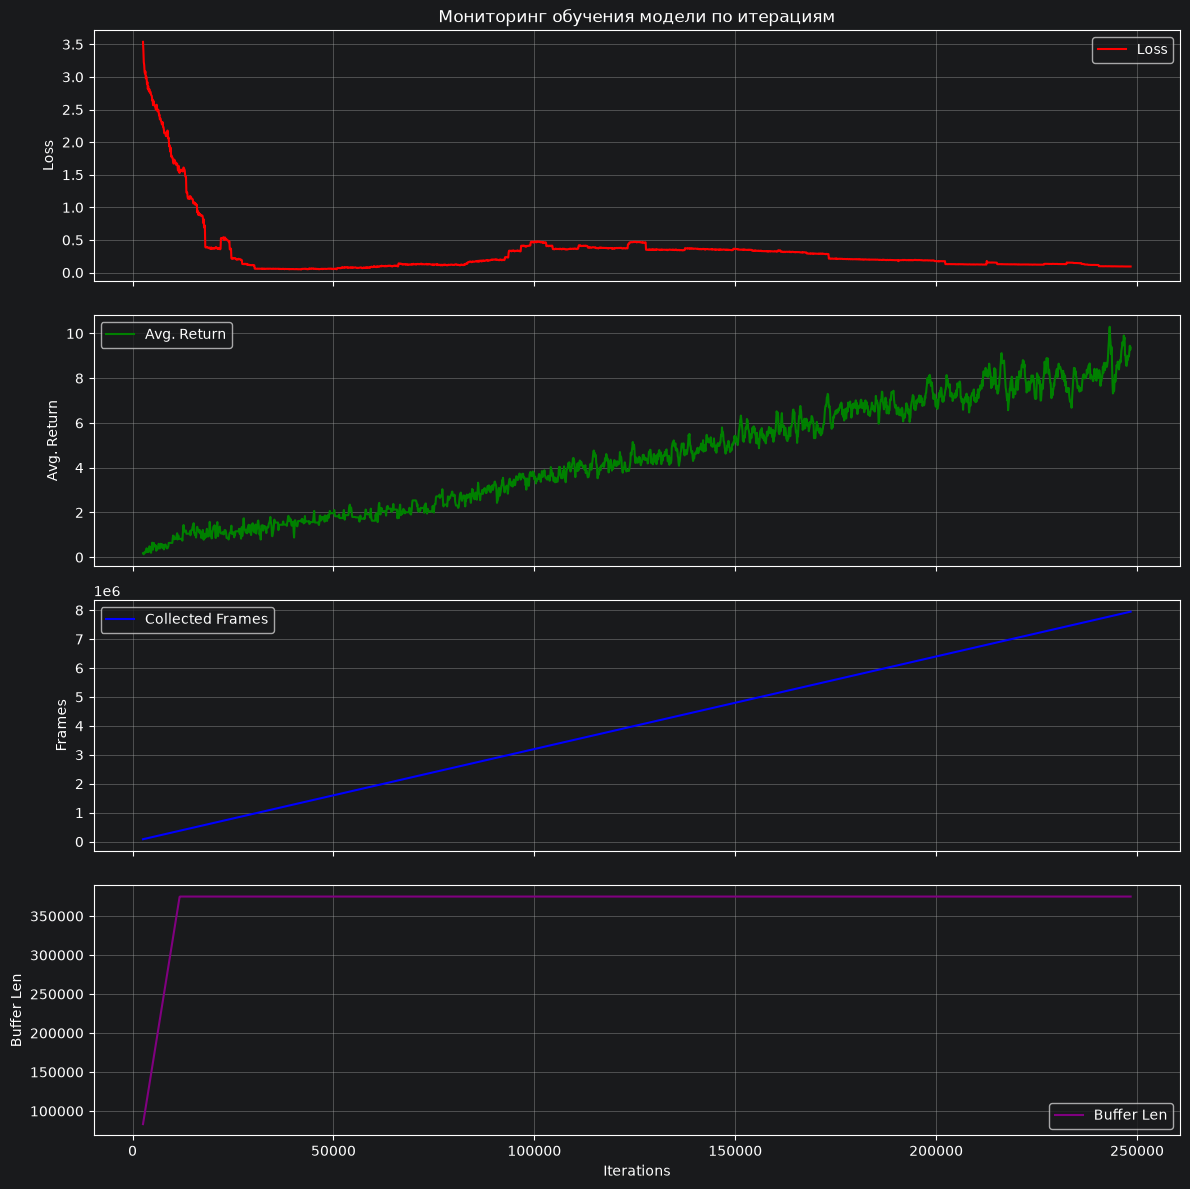

In [3]:
log_file_path: str = "/Users/klimdajneko/Desktop/IT/Portfolio/RainbowBreakOut/experience/rainbow.log"

seconds: list[int | float] = []
pid_or_id: list[int | float] = []
iterations: list[int | float] = []
losses: list[int | float] = []
avg_returns: list[int | float] = []
frames: list[int | float] = []
buffer_lens: list[int | float] = []

log_pattern = re.compile(
    r"(\d+\.\d+)s\s+(\d+)\s+"
    r"Iteration:\s+(\d+)/\d+;"
    r"\s+Loss:\s+(\d+\.\d+);"
    r"\s+Avg\.\s+return:\s+(-?\d+\.\d+);"
    r"\s*Collected frames:\s+(\d+);"
    r"\s+Buffer len:\s+(\d+)\."
)

with open(log_file_path, "r", encoding="utf-8") as f:
    for line in f:
        match = log_pattern.search(line)
        if match:
            seconds.append(float(match.group(1)))  # Время в секундах (38811.6)
            pid_or_id.append(int(match.group(2)))  # ID / PID процесса (6726)
            iterations.append(int(match.group(3)))  # Текущая итерация (222900)
            losses.append(float(match.group(4)))  # Функция потерь / Loss (0.1245)
            avg_returns.append(float(match.group(5)))  # Средняя награда / Avg. return (7.61)
            frames.append(int(match.group(6)))  # Собрано кадров / Collected frames (7132800)
            buffer_lens.append(int(match.group(7)))  # Размер буфера / Buffer len (375000)

# Построение сетки из 4 графиков (ось X у всех общая — Iterations)
fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# 1. График Loss (изменение ошибки)
axs[0].plot(iterations, losses, color="red", label="Loss")
axs[0].set_ylabel("Loss")
axs[0].grid(True)
axs[0].legend()
axs[0].set_title("Мониторинг обучения модели по итерациям")

# 2. График Avg. Return (качество обучения)
axs[1].plot(iterations, avg_returns, color="green", label="Avg. Return")
axs[1].set_ylabel("Avg. Return")
axs[1].grid(True)
axs[1].legend()

# 3. График Collected Frames (динамика сбора данных)
axs[2].plot(iterations, frames, color="blue", label="Collected Frames")
axs[2].set_ylabel("Frames")
axs[2].grid(True)
axs[2].legend()

# 4. График Buffer Len (наполнение буфера)
axs[3].plot(iterations, buffer_lens, color="purple", label="Buffer Len")
axs[3].set_ylabel("Buffer Len")
axs[3].set_xlabel("Iterations")
axs[3].grid(True)
axs[3].legend()

plt.tight_layout()
plt.show()